In [ ]:
import zipfile

zip_ref = zipfile.ZipFile('/content/dataset.zip', 'r')
zip_ref.extractall('/content/dataset')
zip_ref.close()

print("Dataset berhasil di extract")

Dataset berhasil di extract


In [ ]:
import os

dataset_path = '/content/dataset/dataset'

print(os.listdir(dataset_path))

['Arial', 'CourierNew', 'Calibri', 'TimesNewRoman']


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

In [ ]:
classes = ['Arial', 'Calibri', 'CourierNew', 'TimesNewRoman']

data = []
label = []

for kelas in classes:

    path = os.path.join(dataset_path, kelas)

    class_num = classes.index(kelas)

    for img in os.listdir(path):

        img_array = cv2.imread(os.path.join(path, img))

        img_array = cv2.resize(img_array, (64,64))

        data.append(img_array)

        label.append(class_num)

print("Dataset berhasil dibaca")

Dataset berhasil dibaca


In [ ]:
data = np.array(data)
label = np.array(label)

print(data.shape)
print(label.shape)

(40, 64, 64, 3)
(40,)


In [ ]:
data = data / 255.0

In [ ]:
label = to_categorical(label)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data,
    label,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(32, 64, 64, 3)
(8, 64, 64, 3)


In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,668 (6.20 MB)

 Trainable params: 1,625,668 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2812 - loss: 1.3893 - val_accuracy: 0.1250 - val_loss: 6.8262
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.2812 - loss: 4.7387 - val_accuracy: 0.1250 - val_loss: 2.5415
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.2812 - loss: 1.6318 - val_accuracy: 0.1250 - val_loss: 1.6866
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.2812 - loss: 1.4508 - val_accuracy: 0.1250 - val_loss: 1.4834
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.2812 - loss: 1.3683 - val_accuracy: 0.3750 - val_loss: 1.3767
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.5312 - loss: 1.3394 - val_accuracy: 0.3750 - val_loss: 1.3137
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.5312 - loss: 1.3104 - val_accuracy: 0.3750 - val_loss: 1.2799
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.5312 - loss: 1.2687 - val_accuracy: 0.3750 - val_loss: 1.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3750 - loss: 1.3177
Accuracy: 0.375


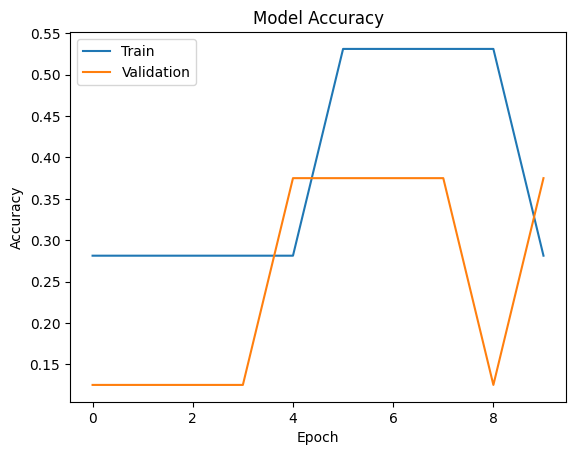

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

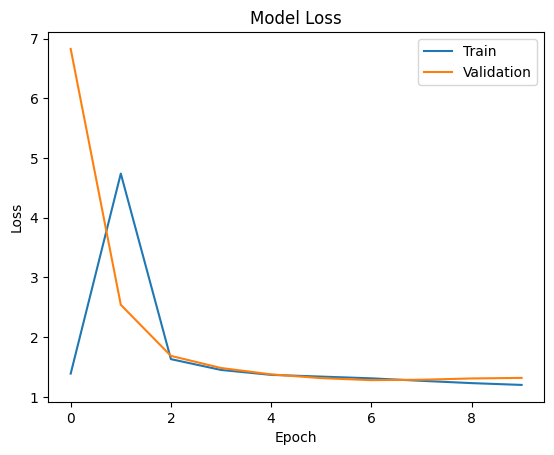

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
model.save('font_cnn_model.h5')